# LINCS → AnnData

Builds an AnnData object from the LINCS Cell Painting profiles in the [Cell Painting Gallery](https://broadinstitute.github.io/cellpainting-gallery/) (`cpg0004-lincs`, also catalogued as idr0125).
One observation is a well, one variable is a CellProfiler feature.

A549 cells, 1,571 compounds at six doses, batch `2016_04_01_a549_48hr_batch1`.
Profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_dmso.csv.gz" \
  s3://cellpainting-gallery/cpg0004-lincs/broad/workspace/profiles/2016_04_01_a549_48hr_batch1/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0004-lincs/profiles_dmso").expanduser()

## Which variant, and why not the feature-selected one

`_normalized_dmso` is normalized per plate against the DMSO wells.

The feature-selected variants are unusable across plates here: LINCS ran feature selection per *plate*, so all 270 plates carry different feature sets and their intersection is 30 features.
The unselected profiles agree far better — most plates share 1,810 columns — so the small residual disagreement can be intersected away.

In [2]:
files = sorted(PROFILES.glob("*/*/*.csv.gz"))
adata = cpio.read_profiles(files, index_columns=("Plate", "Well"), on_column_mismatch="intersect")
print(f"{len(files)} plates -> {adata.n_obs:,} wells x {adata.n_vars:,} features")

136 plates -> 52,223 wells x 1,745 features


In [3]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
for column in ["Plate", "pert_type", "dose_recode", "Batch_Number", "clinical_phase"]:
    adata.obs[column] = adata.obs[column].astype("category")
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_Area,cells,areashape,NaN,NaN,0
Cells_AreaShape_Center_X,cells,areashape,NaN,NaN,0
Cells_AreaShape_Center_Y,cells,areashape,NaN,NaN,0
Cells_AreaShape_Compactness,cells,areashape,NaN,NaN,0
Cells_AreaShape_Eccentricity,cells,areashape,NaN,NaN,0
...,...,...,...,...,...
Nuclei_Texture_Variance_Mito_20_0,nuclei,texture,mito,NaN,1
Nuclei_Texture_Variance_Mito_5_0,nuclei,texture,mito,NaN,1
Nuclei_Texture_Variance_RNA_10_0,nuclei,texture,rna,NaN,1


## Features that blew up

Normalizing against the DMSO wells divides by their median absolute deviation, and where that is near zero for a plate the result explodes.
Values reach 1e19, which is enough to break the PCA solver outright rather than merely distort it.

The affected features are almost all `Correlation_Costes_*`, a colocalization statistic that is unstable when one channel is close to empty.
The magnitudes are bimodal — nearly everything sits below 1e4 and the broken features sit above 1e9 — so the cut is not delicate.

In [4]:
largest = np.abs(adata.X).max(axis=0)
print(f"features with max|x| > 1e6: {int((largest > 1e6).sum())} of {adata.n_vars}")
print(adata.var_names[largest > 1e6][:5].tolist())

adata = cpio.drop_extreme_features(adata)
print(f"kept {adata.n_vars:,} features, max|x| now {np.abs(adata.X).max():.1f}")

features with max|x| > 1e6: 136 of 1739
['Cells_Correlation_Costes_AGP_DNA', 'Cells_Correlation_Costes_AGP_Mito', 'Cells_Correlation_Costes_AGP_RNA', 'Cells_Correlation_Costes_DNA_AGP', 'Cells_Correlation_Costes_DNA_ER']


kept 1,603 features, max|x| now 45646.0


## Sanity checks

`dose_recode` is an ordinal dose index, 1 being the lowest; DMSO controls carry their own level.

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features across {adata.obs['Plate'].nunique()} plates")
print(f"compounds: {adata.obs['pert_iname'].nunique():,} | non-finite: {int((~np.isfinite(adata.X)).sum())}")
print(adata.obs["dose_recode"].value_counts().sort_index().to_string())
print(adata.obs["pert_type"].value_counts().to_string())

52,223 wells x 1,603 features across 136 plates
compounds: 1,511 | non-finite: 0
dose_recode
1    10954
2     7616
3     7616
4     7616
5     7589
6     7568
7     3264
pert_type
trt        48959
control     3264


In [6]:
adata.write_h5ad(PROFILES.parent / "lincs_2016_04_01_a549_48hr_batch1.h5ad")

## UMAP

Already normalized per plate, so no further scaling.

In [7]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
cpio.neighbour_enrichment(adata, ["Plate", "Batch_Number", "pert_type", "dose_recode", "clinical_phase"])

,observed,baseline,ratio
covariate,,,
Plate,0.169,0.007,22.952
Batch_Number,0.570,0.201,2.839
pert_type,0.882,0.883,0.999
dose_recode,0.261,0.154,1.697
clinical_phase,0.471,0.379,1.242


Plate dominates by more than twentyfold, with run second and dose modestly enriched.

The treated-versus-control ratio is at chance, but it cannot say much either way here: 94% of wells are treated, so a shuffled baseline already puts two random wells in the same class 88% of the time.
`dose_recode` 7 is the DMSO level rather than a seventh concentration.

`clinical_phase` is included because it is the one annotation here that is about the compound rather than the experiment, so it is worth measuring against the design covariates.

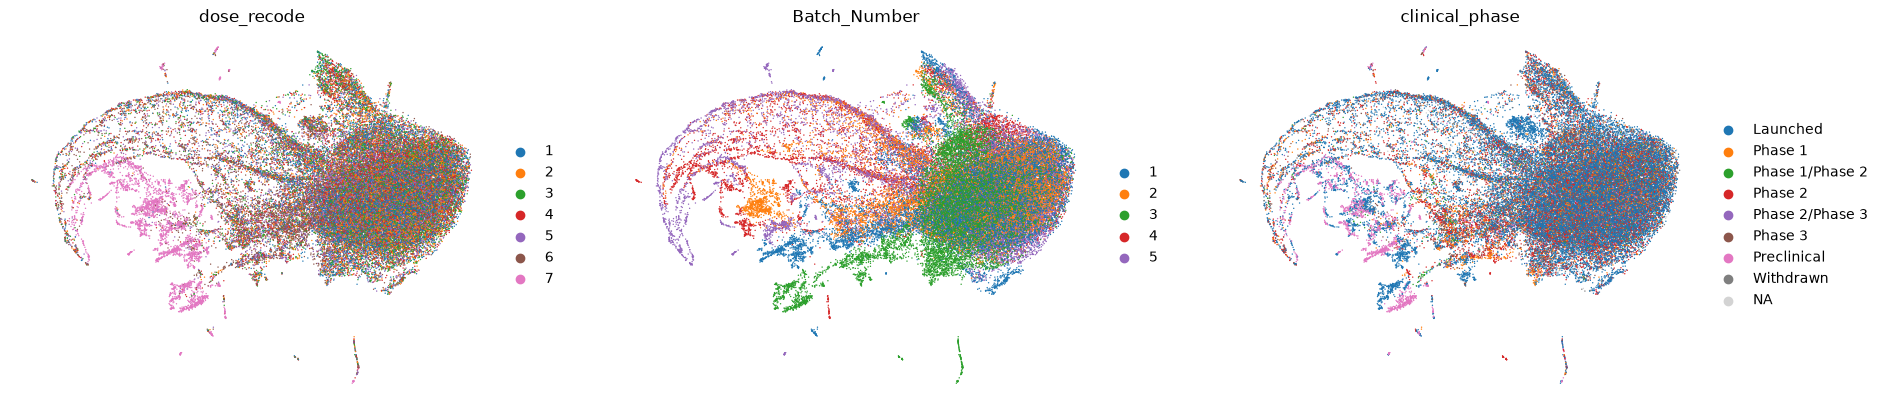

In [9]:
sc.pl.umap(adata, color=["dose_recode", "Batch_Number", "clinical_phase"], ncols=3, frameon=False, size=4)